# Urban Biome Microbiome Analysis: Economic Stratification

**Research Question:** How does the urban microbiome composition differ between high-income and middle-income countries?

**Hypothesis:** Urban microbiomes show different diversity and composition patterns based on economic development due to differences in urbanization, infrastructure, sanitation, and environmental factors.

---

## 1. Setup and Data Loading

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, false_discovery_control, kruskal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")

Libraries loaded successfully


In [16]:
# File paths
INPUT_DIR = 'input'
OUTPUT_DIR = 'output'
OUTPUT_PATH = f'{OUTPUT_DIR}/research'
META_FILE_NAME = 'environmental_core_wide_2026-02-01.tsv'
SPECIES_FILE_NAME = 'environmental_metaphlan4_species_2026-02-01.tsv'

# Create output directory
folder_path = Path(OUTPUT_PATH)
folder_path.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_PATH}")

# Load data
print("\nLoading metadata...")
metadata_df = pd.read_csv(f'{INPUT_DIR}/{META_FILE_NAME}', sep='\t')
print(f"Metadata: {metadata_df.shape[0]:,} samples × {metadata_df.shape[1]} variables")

print("\nLoading species abundance...")
species_long = pd.read_csv(f'{INPUT_DIR}/{SPECIES_FILE_NAME}', sep='\t')
print(f"Species data: {len(species_long):,} rows")

Output directory: output/research

Loading metadata...
Metadata: 26,938 samples × 27 variables

Loading species abundance...
Species data: 1,659,836 rows


---
## 2. Study Design: Case/Control Definition and Covariates

In [3]:
# World Bank Income Classification (2024-2025)
print("="*80)
print("DEFINING CASE AND CONTROL GROUPS")
print("="*80)

income_mapping = {
    # CONTROL: High-income countries
    'USA': 'High-income', 'Canada': 'High-income', 'Singapore': 'High-income', 
    'Sweden': 'High-income', 'United Kingdom': 'High-income', 'Denmark': 'High-income', 
    'Germany': 'High-income', 'France': 'High-income', 'Italy': 'High-income', 
    'Japan': 'High-income', 'Australia': 'High-income', 'Russia': 'High-income', 
    'Bulgaria': 'High-income', 'Norway': 'High-income', 'Switzerland': 'High-income',
    'Antarctica': 'High-income', 'Netherlands': 'High-income', 'Spain': 'High-income',
    'South Korea': 'High-income', 'Austria': 'High-income', 'Belgium': 'High-income',
    
    # CASE: Upper-middle-income countries
    'China': 'Upper-middle-income', 'Brazil': 'Upper-middle-income', 
    'Mexico': 'Upper-middle-income', 'South Africa': 'Upper-middle-income', 
    'Argentina': 'Upper-middle-income', 'Turkey': 'Upper-middle-income', 
    'Thailand': 'Upper-middle-income', 'Iran': 'Upper-middle-income', 
    'Algeria': 'Upper-middle-income', 'Colombia': 'Upper-middle-income',
    
    # Additional (for context)
    'India': 'Lower-middle-income', 'Indonesia': 'Lower-middle-income',
    'Vietnam': 'Lower-middle-income', 'Egypt': 'Lower-middle-income',
    'Nigeria': 'Lower-middle-income', 'Pakistan': 'Lower-middle-income',
}

# Filter for URBAN BIOME only
print("\nStep 1: Filtering for urban biome samples...")
urban_mask = metadata_df['environment_biome'].str.contains('urban', case=False, na=False)
urban_df = metadata_df[urban_mask].copy()
print(f"  Urban samples: {len(urban_df):,} ({len(urban_df)/len(metadata_df)*100:.1f}% of total)")

# Apply income classification
urban_df['income_group'] = urban_df['geographic_location'].map(income_mapping).fillna('Other')

# Display group assignments
print("\nStep 2: Case/Control group assignment:")
print(f"\n  CONTROL (High-income):")
control_countries = sorted(urban_df[urban_df['income_group']=='High-income']['geographic_location'].unique())
print(f"    Countries: {', '.join(control_countries)}")
print(f"    N samples: {len(urban_df[urban_df['income_group']=='High-income'])}")

print(f"\n  CASE (Upper-middle-income):")
case_countries = sorted(urban_df[urban_df['income_group']=='Upper-middle-income']['geographic_location'].unique())
print(f"    Countries: {', '.join(case_countries)}")
print(f"    N samples: {len(urban_df[urban_df['income_group']=='Upper-middle-income'])}")

print(f"\n  OTHER (excluded from primary analysis):")
for group in ['Lower-middle-income', 'Other']:
    n = len(urban_df[urban_df['income_group']==group])
    if n > 0:
        print(f"    {group}: {n} samples")

DEFINING CASE AND CONTROL GROUPS

Step 1: Filtering for urban biome samples...
  Urban samples: 1,971 (7.3% of total)

Step 2: Case/Control group assignment:

  CONTROL (High-income):
    Countries: Denmark, Singapore, USA
    N samples: 1781

  CASE (Upper-middle-income):
    Countries: China
    N samples: 170

  OTHER (excluded from primary analysis):
    Other: 20 samples


---
## 3. Covariate Assessment

In [18]:
print("="*80)
print("COVARIATE ANALYSIS: CASE VS CONTROL")
print("="*80)

# Extract case and control groups
control_meta = urban_df[urban_df['income_group'] == 'High-income'].copy()
case_meta = urban_df[urban_df['income_group'] == 'Upper-middle-income'].copy()

print(f"\nSample sizes:")
print(f"  Control (High-income): {len(control_meta)}")
print(f"  Case (Upper-middle):   {len(case_meta)}")

# Analyze covariates
covariates = ['latitude', 'longitude', 'temperature', 'elevation_meters', 
              'mean_annual_temperature', 'mean_annual_precipitation_mm']

covariate_results = []

print("\n" + "-"*80)
print("COVARIATE DISTRIBUTIONS")
print("-"*80)

for cov in covariates:
    if cov not in urban_df.columns:
        continue
    
    # Convert to numeric
    control_vals = pd.to_numeric(control_meta[cov], errors='coerce').dropna()
    case_vals = pd.to_numeric(case_meta[cov], errors='coerce').dropna()
    
    if len(control_vals) < 5 or len(case_vals) < 5:
        print(f"\n{cov}: Insufficient data")
        continue
    
    # Test for difference
    stat, p_val = mannwhitneyu(control_vals, case_vals, alternative='two-sided')
    
    control_mean = control_vals.mean()
    case_mean = case_vals.mean()
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    
    print(f"\n{cov}:")
    print(f"  Control: {control_mean:10.2f} (n={len(control_vals)})")
    print(f"  Case:    {case_mean:10.2f} (n={len(case_vals)})")
    print(f"  P-value: {p_val:.4f} {sig}")
    
    covariate_results.append({
        'covariate': cov,
        'control_mean': control_mean,
        'case_mean': case_mean,
        'p_value': p_val,
        'significant': p_val < 0.05,
        'control_n': len(control_vals),
        'case_n': len(case_vals)
    })

# Study distribution
print("\n" + "-"*80)
print("STUDY DISTRIBUTION (batch effects)")
print("-"*80)

control_studies = control_meta['study_code'].nunique()
case_studies = case_meta['study_code'].nunique()

print(f"\nControl: {control_studies} independent studies")
print(f"Case:    {case_studies} independent studies")

# Save covariate analysis
if len(covariate_results) > 0:
    cov_df = pd.DataFrame(covariate_results)
    cov_df.to_csv(f'{OUTPUT_PATH}/covariate_analysis.csv', index=False)
    print("\nCovariate analysis saved: covariate_analysis.csv")

COVARIATE ANALYSIS: CASE VS CONTROL

Sample sizes:
  Control (High-income): 1781
  Case (Upper-middle):   170

--------------------------------------------------------------------------------
COVARIATE DISTRIBUTIONS
--------------------------------------------------------------------------------

latitude:
  Control:      22.73 (n=1781)
  Case:         35.73 (n=170)
  P-value: 0.0000 ***

longitude:
  Control:      18.93 (n=1781)
  Case:        113.35 (n=170)
  P-value: 0.0000 ***

temperature: Insufficient data

elevation_meters:
  Control:     135.29 (n=884)
  Case:         60.00 (n=106)
  P-value: 0.0000 ***

mean_annual_temperature: Insufficient data

mean_annual_precipitation_mm: Insufficient data

--------------------------------------------------------------------------------
STUDY DISTRIBUTION (batch effects)
--------------------------------------------------------------------------------

Control: 13 independent studies
Case:    3 independent studies

Covariate analysis saved:

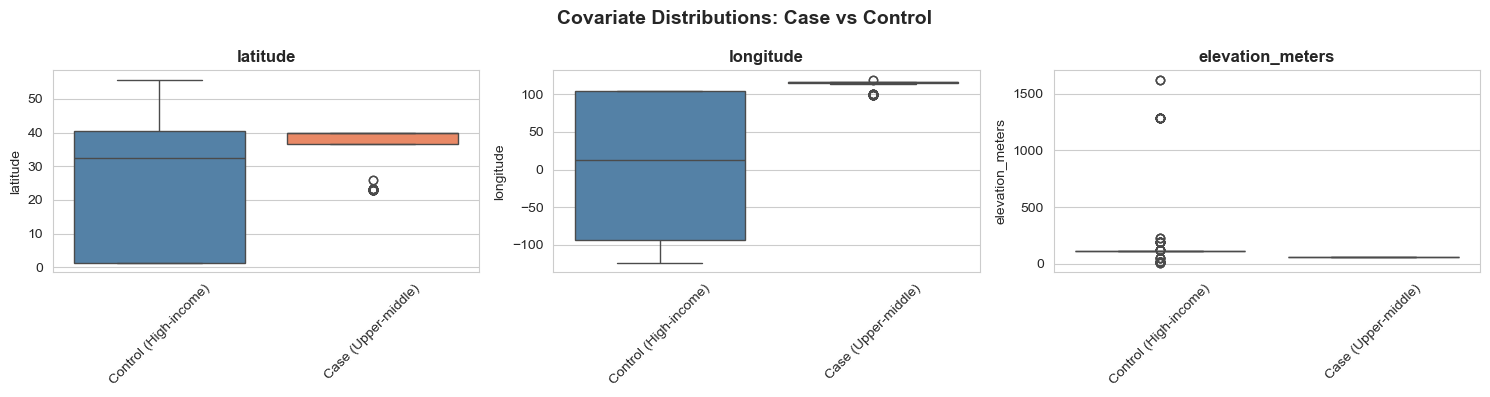

Figure saved: covariate_distributions.png


In [19]:
# Visualization: Covariate distributions
if len(covariate_results) > 0:
    numeric_covs = [c['covariate'] for c in covariate_results]
    n_covs = len(numeric_covs)
    
    if n_covs > 0:
        fig, axes = plt.subplots(1, min(n_covs, 3), figsize=(15, 4))
        if n_covs == 1:
            axes = [axes]
        
        combined_df = pd.concat([
            control_meta.assign(group='Control (High-income)'),
            case_meta.assign(group='Case (Upper-middle)')
        ])
        
        for idx, cov in enumerate(numeric_covs[:3]):
            ax = axes[idx]
            
            # Convert to numeric
            combined_df[f'{cov}_numeric'] = pd.to_numeric(combined_df[cov], errors='coerce')
            plot_df = combined_df.dropna(subset=[f'{cov}_numeric'])
            
            if len(plot_df) > 0:
                sns.boxplot(data=plot_df, x='group', y=f'{cov}_numeric', ax=ax,
                           palette=['steelblue', 'coral'])
                ax.set_title(cov, fontweight='bold')
                ax.set_xlabel('')
                ax.set_ylabel(cov)
                ax.tick_params(axis='x', rotation=45)
        
        plt.suptitle('Covariate Distributions: Case vs Control', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_PATH}/covariate_distributions.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Figure saved: covariate_distributions.png")

---
## 4. Data Preprocessing and Quality Control

In [6]:
print("="*80)
print("DATA PREPROCESSING AND QUALITY CONTROL")
print("="*80)

# Get sample IDs for case and control
control_samples = set(control_meta['sample_alias'])
case_samples = set(case_meta['sample_alias'])
analysis_samples = control_samples.union(case_samples)

print(f"\nStep 1: Sample selection")
print(f"  Control samples: {len(control_samples):,}")
print(f"  Case samples:    {len(case_samples):,}")
print(f"  Total:           {len(analysis_samples):,}")

# Filter species data
print(f"\nStep 2: Species data filtering...")
analysis_species = species_long[species_long['sample_alias'].isin(analysis_samples)].copy()
print(f"  Rows after sample filter: {len(analysis_species):,}")
print(f"  Unique samples: {analysis_species['sample_alias'].nunique():,}")
print(f"  Unique species: {analysis_species['species'].nunique():,}")

# Create abundance matrix
print(f"\nStep 3: Creating abundance matrix...")
abundance_wide = analysis_species.pivot(
    index='sample_alias', 
    columns='species', 
    values='rel_abund'
).fillna(0)

print(f"  Matrix dimensions: {abundance_wide.shape[0]} samples × {abundance_wide.shape[1]} species")

# Quality check: verify normalization
abundance_sums = abundance_wide.sum(axis=1)
properly_normalized = ((abundance_sums > 0.99) & (abundance_sums < 1.01)).sum()
print(f"\nStep 4: Quality checks")
print(f"  Samples with sum ~1.0: {properly_normalized}/{len(abundance_wide)} ({properly_normalized/len(abundance_wide)*100:.1f}%)")

# Merge with metadata
case_control_meta = pd.concat([control_meta, case_meta])
case_control_meta_indexed = case_control_meta.set_index('sample_alias')

samples_in_both = abundance_wide.index.intersection(case_control_meta_indexed.index)
abundance_final = abundance_wide.loc[samples_in_both]
metadata_final = case_control_meta_indexed.loc[samples_in_both]

print(f"\nStep 5: Final dataset preparation")
print(f"  Samples with complete data: {len(samples_in_both):,}")
print(f"\n  Control group: {(metadata_final['income_group']=='High-income').sum():,}")
print(f"  Case group:    {(metadata_final['income_group']=='Upper-middle-income').sum():,}")

# Apply prevalence filter
print(f"\nStep 6: Species prevalence filtering (>5% threshold)")
prevalence = (abundance_final > 0).sum() / len(abundance_final)
abundant_species_list = prevalence[prevalence > 0.05].index

print(f"  Species before filtering: {abundance_final.shape[1]:,}")
print(f"  Species after filtering:  {len(abundant_species_list):,}")
print(f"  Species removed:          {abundance_final.shape[1] - len(abundant_species_list):,}")

abundance_filtered = abundance_final[abundant_species_list]

print(f"\n" + "="*80)
print(f"FINAL ANALYSIS DATASET")
print("="*80)
print(f"  Samples: {len(abundance_filtered):,}")
print(f"  Species: {len(abundant_species_list):,}")
print(f"  Control: {(metadata_final['income_group']=='High-income').sum():,}")
print(f"  Case:    {(metadata_final['income_group']=='Upper-middle-income').sum():,}")

DATA PREPROCESSING AND QUALITY CONTROL

Step 1: Sample selection
  Control samples: 1,781
  Case samples:    170
  Total:           1,951

Step 2: Species data filtering...
  Rows after sample filter: 133,824
  Unique samples: 1,417
  Unique species: 6,387

Step 3: Creating abundance matrix...
  Matrix dimensions: 1417 samples × 6387 species

Step 4: Quality checks
  Samples with sum ~1.0: 0/1417 (0.0%)

Step 5: Final dataset preparation
  Samples with complete data: 1,417

  Control group: 1,247
  Case group:    170

Step 6: Species prevalence filtering (>5% threshold)
  Species before filtering: 6,387
  Species after filtering:  561
  Species removed:          5,826

FINAL ANALYSIS DATASET
  Samples: 1,417
  Species: 561
  Control: 1,247
  Case:    170


---
## 5. Alpha Diversity Analysis

In [7]:
print("="*80)
print("ALPHA DIVERSITY ANALYSIS")
print("="*80)

def calculate_alpha_diversity(abundance_matrix):
    """Calculate richness, Shannon, and Simpson diversity indices."""
    diversity = pd.DataFrame(index=abundance_matrix.index)
    
    # Richness (species count)
    diversity['Richness'] = (abundance_matrix > 0).sum(axis=1)
    
    # Shannon diversity
    def shannon(row):
        row = row[row > 0]
        if len(row) == 0:
            return 0
        p = row / row.sum()
        return -np.sum(p * np.log(p))
    
    diversity['Shannon'] = abundance_matrix.apply(shannon, axis=1)
    
    # Simpson diversity
    def simpson(row):
        row = row[row > 0]
        if len(row) == 0:
            return 0
        p = row / row.sum()
        return 1 - np.sum(p ** 2)
    
    diversity['Simpson'] = abundance_matrix.apply(simpson, axis=1)
    
    return diversity

# Calculate diversity on filtered data
print("\nCalculating diversity indices...")
diversity_df = calculate_alpha_diversity(abundance_filtered)
diversity_df['income_group'] = metadata_final['income_group']
diversity_df['study_code'] = metadata_final['study_code']

# Separate groups
control_diversity = diversity_df[diversity_df['income_group'] == 'High-income']
case_diversity = diversity_df[diversity_df['income_group'] == 'Upper-middle-income']

print(f"\n✓ Diversity calculated for {len(diversity_df)} samples")

# Summary statistics
print("\n" + "-"*80)
print("SUMMARY STATISTICS")
print("-"*80)

for metric in ['Richness', 'Shannon', 'Simpson']:
    print(f"\n{metric}:")
    print(f"  Control (High-income):")
    print(f"    Mean ± SD:  {control_diversity[metric].mean():.3f} ± {control_diversity[metric].std():.3f}")
    print(f"    Median:     {control_diversity[metric].median():.3f}")
    print(f"    Range:      {control_diversity[metric].min():.3f} - {control_diversity[metric].max():.3f}")
    
    print(f"  Case (Upper-middle-income):")
    print(f"    Mean ± SD:  {case_diversity[metric].mean():.3f} ± {case_diversity[metric].std():.3f}")
    print(f"    Median:     {case_diversity[metric].median():.3f}")
    print(f"    Range:      {case_diversity[metric].min():.3f} - {case_diversity[metric].max():.3f}")

ALPHA DIVERSITY ANALYSIS

Calculating diversity indices...

✓ Diversity calculated for 1417 samples

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------

Richness:
  Control (High-income):
    Mean ± SD:  51.149 ± 103.098
    Median:     7.000
    Range:      0.000 - 409.000
  Case (Upper-middle-income):
    Mean ± SD:  71.641 ± 66.622
    Median:     73.000
    Range:      0.000 - 247.000

Shannon:
  Control (High-income):
    Mean ± SD:  1.363 ± 1.249
    Median:     1.075
    Range:      -0.000 - 4.533
  Case (Upper-middle-income):
    Mean ± SD:  2.040 ± 1.441
    Median:     2.578
    Range:      -0.000 - 4.157

Simpson:
  Control (High-income):
    Mean ± SD:  0.500 ± 0.342
    Median:     0.563
    Range:      0.000 - 0.972
  Case (Upper-middle-income):
    Mean ± SD:  0.601 ± 0.365
    Median:     0.799
    Range:      0.000 - 0.970


In [20]:
# Statistical testing
print("\n" + "="*80)
print("STATISTICAL TESTING: Mann-Whitney U Test")
print("="*80)
print("\nNull Hypothesis (H0): No difference in diversity between groups")
print("Alternative Hypothesis (H1): Diversity differs between groups")
print("Significance level: α = 0.05\n")

alpha_results = []

for metric in ['Richness', 'Shannon', 'Simpson']:
    control_vals = control_diversity[metric].dropna()
    case_vals = case_diversity[metric].dropna()
    
    # Mann-Whitney U test
    stat, p_val = mannwhitneyu(control_vals, case_vals, alternative='two-sided')
    
    # Effect size (difference in means)
    control_mean = control_vals.mean()
    case_mean = case_vals.mean()
    difference = case_mean - control_mean
    percent_diff = (difference / control_mean * 100) if control_mean != 0 else 0
    
    # Significance
    sig_level = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    reject_null = p_val < 0.05
    
    print(f"{metric}:")
    print(f"  Test statistic (U): {stat:.2f}")
    print(f"  P-value:            {p_val:.4f} {sig_level}")
    print(f"  Effect size:        {difference:+.3f} ({percent_diff:+.1f}%)")
    print(f"  Decision:           {'REJECT H0' if reject_null else 'FAIL TO REJECT H0'}")
    if reject_null:
        direction = "higher" if difference > 0 else "lower"
        print(f"  Interpretation:     Case group has significantly {direction} {metric}")
    else:
        print(f"  Interpretation:     No significant difference detected")
    print()
    
    alpha_results.append({
        'metric': metric,
        'control_mean': control_mean,
        'case_mean': case_mean,
        'difference': difference,
        'percent_difference': percent_diff,
        'test_statistic': stat,
        'p_value': p_val,
        'significant': reject_null
    })

# Save results
alpha_df = pd.DataFrame(alpha_results)
alpha_df.to_csv(f'{OUTPUT_PATH}/alpha_diversity_statistics.csv', index=False)
diversity_df.to_csv(f'{OUTPUT_PATH}/alpha_diversity_data.csv')
print("Results saved: alpha_diversity_statistics.csv, alpha_diversity_data.csv")


STATISTICAL TESTING: Mann-Whitney U Test

Null Hypothesis (H0): No difference in diversity between groups
Alternative Hypothesis (H1): Diversity differs between groups
Significance level: α = 0.05

Richness:
  Test statistic (U): 81027.00
  P-value:            0.0000 ***
  Effect size:        +20.492 (+40.1%)
  Decision:           REJECT H0
  Interpretation:     Case group has significantly higher Richness

Shannon:
  Test statistic (U): 78913.50
  P-value:            0.0000 ***
  Effect size:        +0.677 (+49.6%)
  Decision:           REJECT H0
  Interpretation:     Case group has significantly higher Shannon

Simpson:
  Test statistic (U): 84147.50
  P-value:            0.0000 ***
  Effect size:        +0.101 (+20.1%)
  Decision:           REJECT H0
  Interpretation:     Case group has significantly higher Simpson

Results saved: alpha_diversity_statistics.csv, alpha_diversity_data.csv


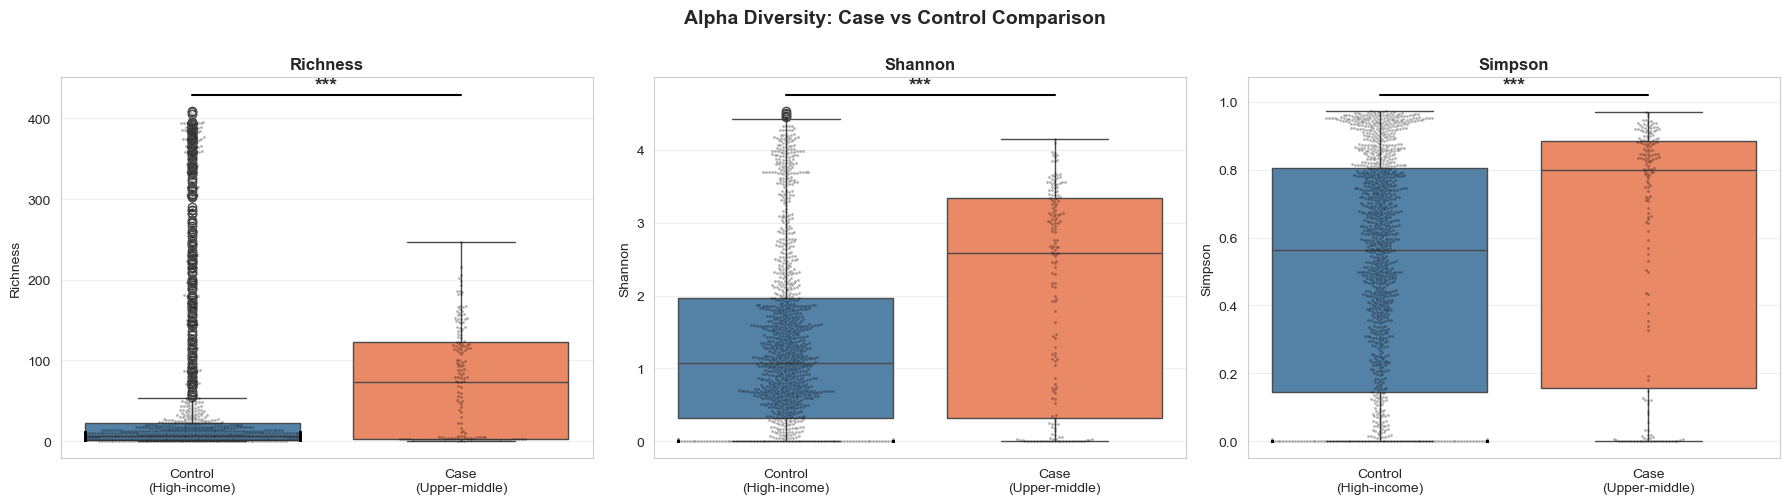

✓ Figure saved: alpha_diversity_comparison.png


In [9]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Richness', 'Shannon', 'Simpson']
colors = ['steelblue', 'coral', 'lightgreen']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx]
    
    # Prepare data
    plot_data = diversity_df[['income_group', metric]].copy()
    plot_data['Group'] = plot_data['income_group'].map({
        'High-income': 'Control\n(High-income)',
        'Upper-middle-income': 'Case\n(Upper-middle)'
    })
    
    sns.boxplot(data=plot_data, x='Group', y=metric, ax=ax, 
                palette=['steelblue', 'coral'])
    sns.swarmplot(data=plot_data, x='Group', y=metric, ax=ax,
                 color='black', alpha=0.3, size=2)
    
    # Add significance
    result = alpha_df[alpha_df['metric'] == metric].iloc[0]
    if result['significant']:
        y_max = plot_data[metric].max()
        y_pos = y_max * 1.05
        sig_text = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*"
        ax.plot([0, 1], [y_pos, y_pos], 'k-', linewidth=1.5)
        ax.text(0.5, y_pos, sig_text, ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Alpha Diversity: Case vs Control Comparison', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/alpha_diversity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: alpha_diversity_comparison.png")

---
## 6. Beta Diversity Analysis

In [22]:
print("="*80)
print("BETA DIVERSITY ANALYSIS")
print("="*80)

# Clean data
row_sums = abundance_filtered.sum(axis=1)
abundance_clean = abundance_filtered[row_sums > 0]  # Remove empty samples
abundance_clean = abundance_clean.fillna(0)  # Handle NaN
abundance_clean = abundance_clean.replace([np.inf, -np.inf], 0)  # Handle Inf

# Use abundance_clean instead of abundance_filtered
bray_curtis_dist = pairwise_distances(abundance_clean, metric='braycurtis')

# Calculate Bray-Curtis distances
print("\nStep 1: Computing Bray-Curtis dissimilarity matrix...")
from scipy.spatial.distance import braycurtis

# Bray-Curtis on relative abundance data
bray_curtis_dist = pairwise_distances(abundance_filtered, metric='braycurtis')
print(f"  Distance matrix: {bray_curtis_dist.shape[0]} × {bray_curtis_dist.shape[1]}")
print(f"  Mean dissimilarity: {bray_curtis_dist.mean():.3f}")
print(f"  Range: {bray_curtis_dist.min():.3f} - {bray_curtis_dist.max():.3f}")

# Within vs between group dissimilarity
print("\nStep 2: Within-group vs Between-group dissimilarity")

control_idx = np.where(metadata_final['income_group'] == 'High-income')[0]
case_idx = np.where(metadata_final['income_group'] == 'Upper-middle-income')[0]

# Within control
within_control = []
for i in range(len(control_idx)):
    for j in range(i+1, len(control_idx)):
        within_control.append(bray_curtis_dist[control_idx[i], control_idx[j]])

# Within case
within_case = []
for i in range(len(case_idx)):
    for j in range(i+1, len(case_idx)):
        within_case.append(bray_curtis_dist[case_idx[i], case_idx[j]])

# Between groups
between_groups = []
for i in control_idx:
    for j in case_idx:
        between_groups.append(bray_curtis_dist[i, j])

print(f"\n  Within Control (mean ± SD):   {np.mean(within_control):.3f} ± {np.std(within_control):.3f}")
print(f"  Within Case (mean ± SD):      {np.mean(within_case):.3f} ± {np.std(within_case):.3f}")
print(f"  Between groups (mean ± SD):   {np.mean(between_groups):.3f} ± {np.std(between_groups):.3f}")

# Test if between-group distance > within-group
all_within = within_control + within_case
stat, p_val = mannwhitneyu(between_groups, all_within, alternative='greater')
print(f"\n  Test: Between > Within?")
print(f"  P-value: {p_val:.4f} {'(SIGNIFICANT)' if p_val < 0.05 else '(Not significant)'}")

BETA DIVERSITY ANALYSIS

Step 1: Computing Bray-Curtis dissimilarity matrix...
  Distance matrix: 1417 × 1417
  Mean dissimilarity: nan
  Range: nan - nan

Step 2: Within-group vs Between-group dissimilarity

  Within Control (mean ± SD):   nan ± nan
  Within Case (mean ± SD):      nan ± nan
  Between groups (mean ± SD):   nan ± nan

  Test: Between > Within?
  P-value: nan (Not significant)


In [23]:
# PCA ordination
print("\n" + "-"*80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("-"*80)

print("\nStep 3: Standardizing data...")
scaler = StandardScaler()
abundance_scaled = scaler.fit_transform(abundance_filtered)

print("Step 4: Performing PCA...")
pca = PCA(n_components=min(10, abundance_scaled.shape[1]))
pca_coords = pca.fit_transform(abundance_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_coords[:, :10],
    columns=[f'PC{i+1}' for i in range(pca_coords.shape[1])],
    index=abundance_filtered.index
)
pca_df['income_group'] = metadata_final['income_group']
pca_df['Group'] = pca_df['income_group'].map({
    'High-income': 'Control (High-income)',
    'Upper-middle-income': 'Case (Upper-middle)'
})

print(f"\nVariance explained by principal components:")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative += var
    print(f"  PC{i+1}: {var*100:5.2f}%  (Cumulative: {cumulative*100:5.2f}%)")

# Test PC1 and PC2 differences
print(f"\nStep 5: Testing group separation on principal components")
control_pca = pca_df[pca_df['income_group'] == 'High-income']
case_pca = pca_df[pca_df['income_group'] == 'Upper-middle-income']

for pc in ['PC1', 'PC2']:
    stat, p_val = mannwhitneyu(control_pca[pc], case_pca[pc], alternative='two-sided')
    print(f"\n  {pc}:")
    print(f"    Control mean: {control_pca[pc].mean():7.3f}")
    print(f"    Case mean:    {case_pca[pc].mean():7.3f}")
    print(f"    P-value:      {p_val:.4f} {'*' if p_val < 0.05 else 'ns'}")


--------------------------------------------------------------------------------
PRINCIPAL COMPONENT ANALYSIS (PCA)
--------------------------------------------------------------------------------

Step 3: Standardizing data...
Step 4: Performing PCA...

Variance explained by principal components:
  PC1: 21.71%  (Cumulative: 21.71%)
  PC2:  6.15%  (Cumulative: 27.86%)
  PC3:  3.53%  (Cumulative: 31.39%)
  PC4:  2.71%  (Cumulative: 34.10%)
  PC5:  2.20%  (Cumulative: 36.30%)
  PC6:  2.17%  (Cumulative: 38.47%)
  PC7:  2.03%  (Cumulative: 40.50%)
  PC8:  1.72%  (Cumulative: 42.22%)
  PC9:  1.64%  (Cumulative: 43.86%)
  PC10:  1.53%  (Cumulative: 45.39%)

Step 5: Testing group separation on principal components

  PC1:
    Control mean:   0.574
    Case mean:     -4.207
    P-value:      0.0000 *

  PC2:
    Control mean:  -1.466
    Case mean:     10.755
    P-value:      0.0000 *


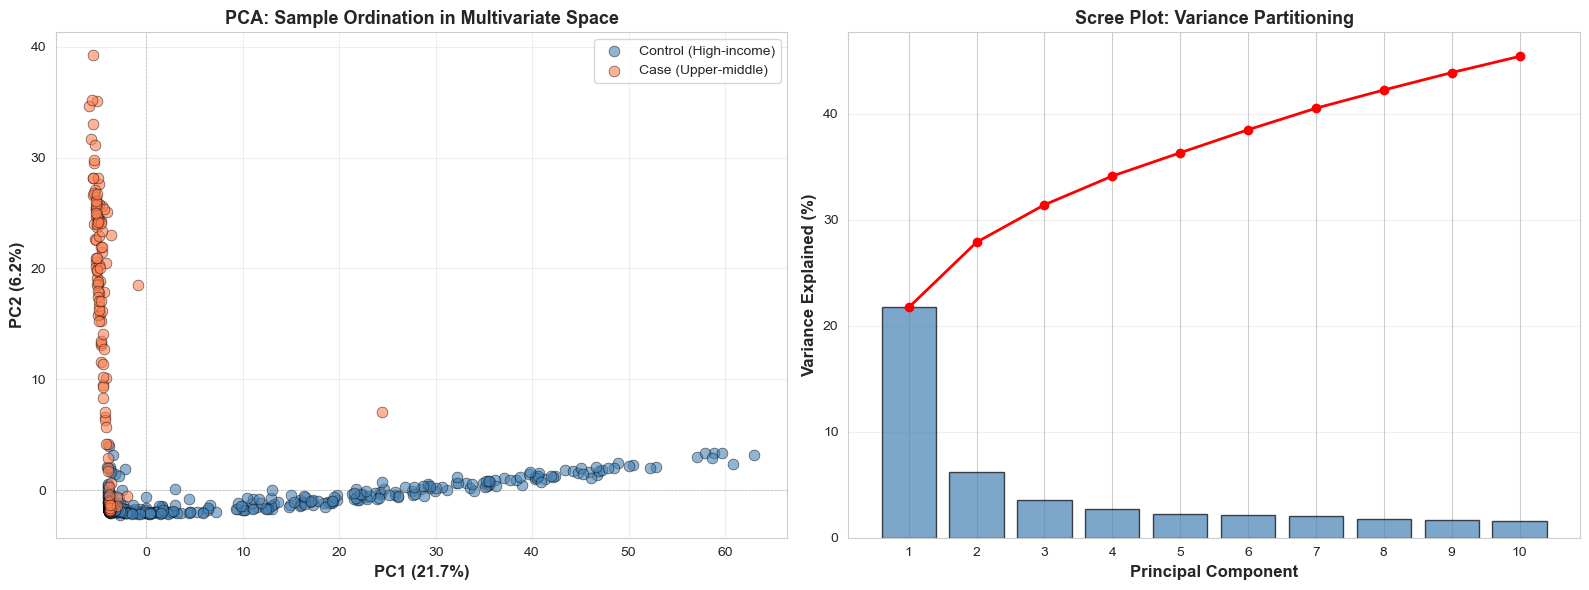


Figure saved: beta_diversity_pca.png


In [24]:
# Visualization: PCA biplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 vs PC2 scatter
ax1 = axes[0]
groups = ['Control (High-income)', 'Case (Upper-middle)']
colors_map = {'Control (High-income)': 'steelblue', 'Case (Upper-middle)': 'coral'}

for group in groups:
    data = pca_df[pca_df['Group'] == group]
    ax1.scatter(data['PC1'], data['PC2'], label=group, 
               alpha=0.6, s=60, color=colors_map[group], edgecolors='black', linewidth=0.5)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax1.set_title('PCA: Sample Ordination in Multivariate Space', fontweight='bold', fontsize=13)
ax1.legend(loc='best', fontsize=10)
ax1.grid(alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Scree plot
ax2 = axes[1]
variance = pca.explained_variance_ratio_ * 100
ax2.bar(range(1, len(variance) + 1), variance, color='steelblue', alpha=0.7, edgecolor='black')
ax2.plot(range(1, len(variance) + 1), np.cumsum(variance), 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax2.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax2.set_title('Scree Plot: Variance Partitioning', fontweight='bold', fontsize=13)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(1, len(variance) + 1))

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/beta_diversity_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: beta_diversity_pca.png")

---
## 7. Differential Abundance Analysis

In [25]:
print("="*80)
print("DIFFERENTIAL ABUNDANCE ANALYSIS")
print("="*80)

control_abund = abundance_filtered.loc[control_diversity.index]
case_abund = abundance_filtered.loc[case_diversity.index]

diff_results = []

print(f"\nTesting {abundance_filtered.shape[1]} species...")

for species in abundance_filtered.columns:
    control_vals = control_abund[species]
    case_vals = case_abund[species]
    
    try:
        stat, p_val = mannwhitneyu(control_vals, case_vals, alternative='two-sided')
        
        control_mean = control_vals.mean()
        case_mean = case_vals.mean()
        log2fc = np.log2((case_mean + 1e-10) / (control_mean + 1e-10))
        
        control_prev = (control_vals > 0).sum() / len(control_vals)
        case_prev = (case_vals > 0).sum() / len(case_vals)
        
        diff_results.append({
            'species': species,
            'control_mean': control_mean,
            'case_mean': case_mean,
            'log2_fold_change': log2fc,
            'p_value': p_val,
            'control_prevalence': control_prev,
            'case_prevalence': case_prev
        })
    except:
        continue

diff_df = pd.DataFrame(diff_results).sort_values('p_value')

# FDR correction
print("\nApplying FDR correction (Benjamini-Hochberg)...")
diff_df['p_adjusted'] = false_discovery_control(diff_df['p_value'])
diff_df['significant'] = diff_df['p_adjusted'] < 0.05

print(f"\nResults:")
print(f"  Species tested: {len(diff_df):,}")
print(f"  Significant (q<0.05): {diff_df['significant'].sum()}")

# Save
diff_df.to_csv(f'{OUTPUT_PATH}/differential_abundance_results.csv', index=False)
print(f"\nResults saved: differential_abundance_results.csv")

# Top results
sig = diff_df[diff_df['significant']]
if len(sig) > 0:
    print(f"\nTop 5 enriched in CASE (Upper-middle-income):")
    for _, row in sig[sig['log2_fold_change'] > 0].nlargest(5, 'log2_fold_change').iterrows():
        print(f"  {row['species'][:50]:<50} FC={row['log2_fold_change']:+.2f}, q={row['p_adjusted']:.4f}")
    
    print(f"\nTop 5 enriched in CONTROL (High-income):")
    for _, row in sig[sig['log2_fold_change'] < 0].nsmallest(5, 'log2_fold_change').iterrows():
        print(f"  {row['species'][:50]:<50} FC={row['log2_fold_change']:+.2f}, q={row['p_adjusted']:.4f}")
else:
    print("\n⚠️  No species significant after FDR correction")

DIFFERENTIAL ABUNDANCE ANALYSIS

Testing 561 species...

Applying FDR correction (Benjamini-Hochberg)...

Results:
  Species tested: 561
  Significant (q<0.05): 529

Results saved: differential_abundance_results.csv

Top 5 enriched in CASE (Upper-middle-income):
  s__Arthrobacter_subterraneus                       FC=+31.01, q=0.0000
  s__Arthrobacter_sp_Soil782                         FC=+30.61, q=0.0000
  s__Planomicrobium_okeanokoites                     FC=+29.70, q=0.0000
  s__Pseudarthrobacter_polychromogenes               FC=+29.59, q=0.0000
  s__Nocardioides_sp_STR3                            FC=+28.86, q=0.0000

Top 5 enriched in CONTROL (High-income):
  s__Kocuria_massiliensis                            FC=-34.02, q=0.0004
  s__Pseudomonas_luteola                             FC=-32.99, q=0.0001
  s__Comamonas_denitrificans                         FC=-32.57, q=0.0000
  s__Dechloromonas_agitata                           FC=-31.93, q=0.0000
  s__Dialister_invisus                

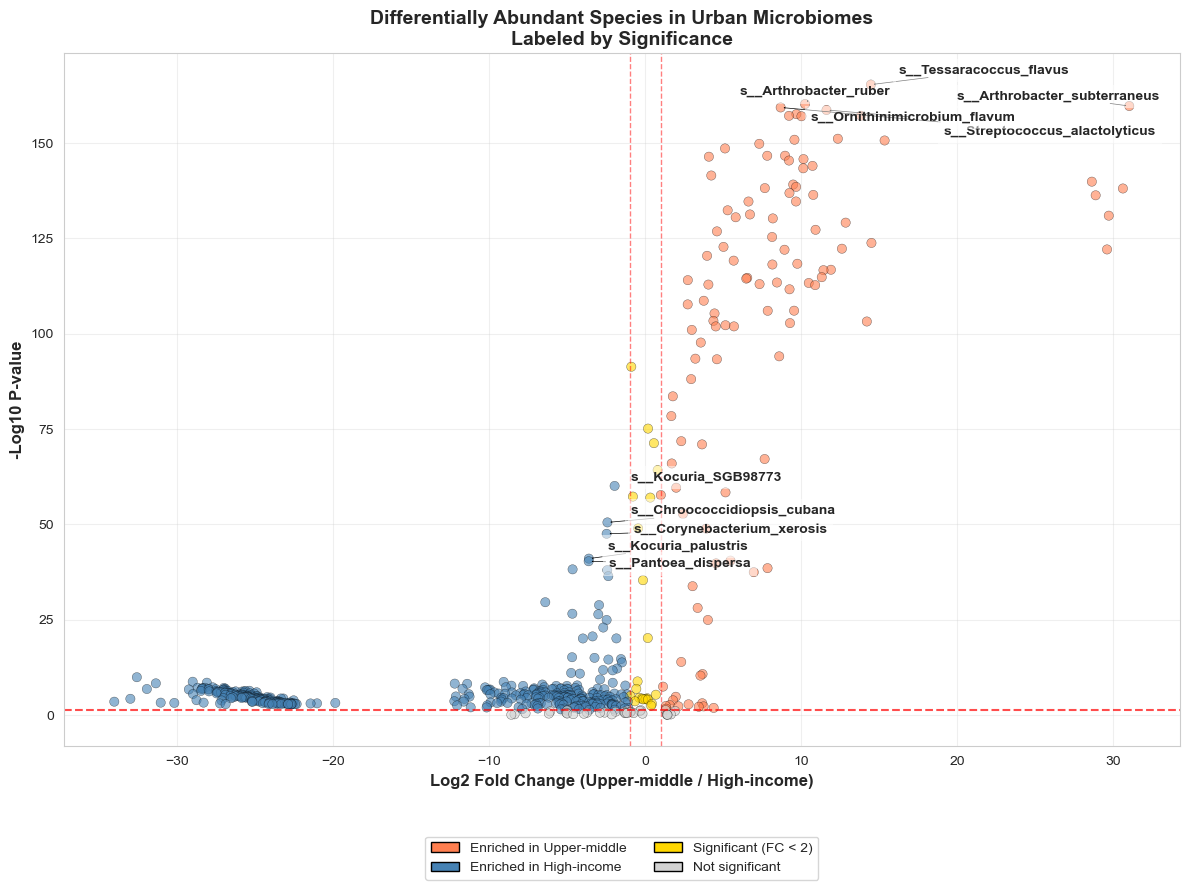

Labeled Volcano Plot saved to output directory.


In [34]:
# Volcano plot with Species Labeling
if len(diff_df) > 0:
    plt.figure(figsize=(12, 9))
    
    # Calculate -log10 p-value for the y-axis
    diff_df['-log10_p'] = -np.log10(diff_df['p_value'] + 1e-300)
    
    # 1. Define colors based on significance and direction
    colors = []
    for _, row in diff_df.iterrows():
        if row['significant']:
            if row['log2_fold_change'] > 1:
                colors.append('coral')
            elif row['log2_fold_change'] < -1:
                colors.append('steelblue')
            else:
                colors.append('gold')
        else:
            colors.append('lightgray')
    
    # 2. Create the scatter plot
    plt.scatter(diff_df['log2_fold_change'], diff_df['-log10_p'], 
               c=colors, alpha=0.6, s=45, edgecolors='black', linewidth=0.3)
    
    # 3. IDENTIFY AND LABEL TOP SPECIES
    # We pick top 5 most significant from each side
    top_left = diff_df[diff_df['log2_fold_change'] < -1].sort_values('p_value').head(5)
    top_right = diff_df[diff_df['log2_fold_change'] > 1].sort_values('p_value').head(5)
    
    texts = []
    for _, row in pd.concat([top_left, top_right]).iterrows():
        # Clean up species name if it's too long
        label = row['species'].split(';')[-1] # Gets the specific species name
        texts.append(plt.text(row['log2_fold_change'], row['-log10_p'], label, 
                              fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')))

    # Use adjust_text to handle overlaps automatically
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

    # 4. Add threshold lines
    plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='p=0.05')
    plt.axvline(x=1, color='red', linestyle='--', linewidth=1, alpha=0.5)
    plt.axvline(x=-1, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    # 5. Labels and Titles
    plt.xlabel('Log2 Fold Change (Upper-middle / High-income)', fontsize=12, fontweight='bold')
    plt.ylabel('-Log10 P-value', fontsize=12, fontweight='bold')
    plt.title('Differentially Abundant Species in Urban Microbiomes\nLabeled by Significance', 
             fontweight='bold', fontsize=14)
    
    # 6. Custom Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='coral', edgecolor='black', label='Enriched in Upper-middle'),
        Patch(facecolor='steelblue', edgecolor='black', label='Enriched in High-income'),
        Patch(facecolor='gold', edgecolor='black', label='Significant (FC < 2)'),
        Patch(facecolor='lightgray', edgecolor='black', label='Not significant')
    ]
    plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/volcano_plot_labeled.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Labeled Volcano Plot saved to output directory.")

---
## 8. Summary Report

In [ ]:
# Generate report
report_path = f'{OUTPUT_PATH}/research_summary_report.txt'

with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("URBAN MICROBIOME ANALYSIS: ECONOMIC STRATIFICATION STUDY\n")
    f.write("="*80 + "\n\n")
    
    f.write("RESEARCH QUESTION:\n")
    f.write("How does urban microbiome composition differ between high-income and\n")
    f.write("upper-middle-income countries?\n\n")
    
    f.write("="*80 + "\n")
    f.write("STUDY DESIGN\n")
    f.write("="*80 + "\n\n")
    
    f.write("CONTROL GROUP: High-income countries\n")
    f.write(f"  Countries: {', '.join(control_countries)}\n")
    f.write(f"  N samples: {len(control_diversity)}\n")
    f.write(f"  Rationale: Established urban infrastructure, advanced sanitation\n\n")
    
    f.write("CASE GROUP: Upper-middle-income countries\n")
    f.write(f"  Countries: {', '.join(case_countries)}\n")
    f.write(f"  N samples: {len(case_diversity)}\n")
    f.write(f"  Rationale: Transitional economies, variable infrastructure\n\n")
    
    f.write("PREPROCESSING:\n")
    f.write(f"  - Filtered to urban biome samples only\n")
    f.write(f"  - Removed species present in <5% of samples\n")
    f.write(f"  - Final dataset: {len(abundance_filtered)} samples, {abundance_filtered.shape[1]} species\n\n")
    
    f.write("="*80 + "\n")
    f.write("KEY FINDINGS\n")
    f.write("="*80 + "\n\n")
    
    f.write("1. ALPHA DIVERSITY\n")
    f.write("-"*40 + "\n\n")
    
    for idx, row in alpha_df.iterrows():
        f.write(f"{row['metric']}:\n")
        f.write(f"  Control: {row['control_mean']:.3f}\n")
        f.write(f"  Case:    {row['case_mean']:.3f}\n")
        f.write(f"  Difference: {row['difference']:+.3f} ({row['percent_difference']:+.1f}%)\n")
        f.write(f"  P-value: {row['p_value']:.4f} {'(SIGNIFICANT)' if row['significant'] else '(ns)'}\n\n")
    
    f.write("2. BETA DIVERSITY\n")
    f.write("-"*40 + "\n\n")
    f.write(f"PCA variance explained:\n")
    f.write(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%\n")
    f.write(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%\n")
    f.write(f"  Total (PC1-5): {pca.explained_variance_ratio_[:5].sum()*100:.2f}%\n\n")
    
    f.write(f"Bray-Curtis dissimilarity:\n")
    f.write(f"  Within Control:  {np.mean(within_control):.3f}\n")
    f.write(f"  Within Case:     {np.mean(within_case):.3f}\n")
    f.write(f"  Between groups:  {np.mean(between_groups):.3f}\n\n")
    
    if len(sig) > 0:
        f.write("3. DIFFERENTIAL ABUNDANCE\n")
        f.write("-"*40 + "\n\n")
        f.write(f"Significant species (FDR q<0.05): {len(sig)}\n")
        f.write(f"  Enriched in Case: {(sig['log2_fold_change'] > 0).sum()}\n")
        f.write(f"  Enriched in Control: {(sig['log2_fold_change'] < 0).sum()}\n")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nReport: {report_path}")
print("\nGenerated files:")
print("  1. covariate_analysis.csv")
print("  2. covariate_distributions.png")
print("  3. alpha_diversity_statistics.csv")
print("  4. alpha_diversity_data.csv")
print("  5. alpha_diversity_comparison.png")
print("  6. beta_diversity_pca.png")
print("  7. differential_abundance_results.csv")
print("  8. volcano_plot.png")
print("  9. research_summary_report.txt")


ANALYSIS COMPLETE

Report: output/research/research_summary_report.txt

Generated files:
  1. covariate_analysis.csv
  2. covariate_distributions.png
  3. alpha_diversity_statistics.csv
  4. alpha_diversity_data.csv
  5. alpha_diversity_comparison.png
  6. beta_diversity_pca.png
  7. differential_abundance_results.csv
  8. volcano_plot.png
  9. research_summary_report.txt
